<a href="https://colab.research.google.com/github/sakshijadhav-08/aiml-assignments-1920/blob/main/19_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Luxury_Scent_Analysis.csv to Luxury_Scent_Analysis.csv


In [ ]:
filepath = './Luxury_Scent_Analysis.csv'
data = pd.read_csv(filepath)
data.head(10)

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"
5,Multiple Brands,Men's Perfume Sampler 10pcs Sample Vials Desig...,Perfume,14.99,US $14.99,10.0,More than 10 available / 79 sold,79.0,"May 23, 2024 06:57:41 PDT","Houston, Texas, United States"
6,Maison Alhambra,Glacier Bold by Maison Alhambra 3.4oz EDP for ...,Eau de Parfum,30.99,US $30.99/ea,9.0,9 available / 39 sold,39.0,"May 16, 2024 13:42:49 PDT","Englewood Cliffs, New Jersey, United States"
7,Unbranded,Parfums De-Marly-Haltane Eau de Parfum spray 4...,Eau de Parfum,85.00,US $85.00,NaN,Last One / 6 sold,6.0,"May 24, 2024 00:10:39 PDT","Ithaca, New York, United States"
8,Unbranded,Hawas for him Eau De Parfum By Rasasi 100ml 3....,/,15.89,US $15.89,10.0,10 available / 17 sold,17.0,"May 24, 2024 09:08:14 PDT","shanghai, China"
9,Gucci,Gucci Guilty for Him - Classic 3oz Eau de Toil...,Eau de Parfum,49.99,US $49.99/ea,8.0,8 available / 68 sold,68.0,"May 23, 2024 07:21:23 PDT","Dearborn Heights, Michigan, United States"


I chose this dataset because it contains information about luxury perfumes and fragrances.

It includes both numerical and categorical features.

The target variable is price, which is continuous in nature.

The dataset can be used to predict the selling price of perfumes.

Factors like brand, fragrance type, availability, and sold quantity may affect the price.

This makes it suitable for a regression problem.

In [ ]:
data.isnull().sum()

,0
brand,1
title,0
type,3
price,0
priceWithCurrency,0
available,111
availableText,3
sold,6
lastUpdated,53
itemLocation,0


In [ ]:
(data.isnull().sum()/len(data))*100

,0
brand,0.1
title,0.0
type,0.3
price,0.0
priceWithCurrency,0.0
available,11.1
availableText,0.3
sold,0.6
lastUpdated,5.3
itemLocation,0.0


In [ ]:
data["sold"] = data["sold"].fillna(data["sold"].median())

In [ ]:
data["type"] = data["type"].fillna("Unknown")

In [ ]:
data.isnull().sum()

,0
brand,1
title,0
type,0
price,0
priceWithCurrency,0
available,111
availableText,3
sold,0
lastUpdated,53
itemLocation,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               1000 non-null   object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          889 non-null    float64
 6   availableText      997 non-null    object 
 7   sold               1000 non-null   float64
 8   lastUpdated        947 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [ ]:
data["brand"] = data["brand"].fillna("Unknown")

In [ ]:
data["availableText"] = data["availableText"].fillna("Unknown")

In [ ]:
data["lastUpdated"] = data["lastUpdated"].fillna("Unknown")

In [ ]:
data["available"] = data["available"].fillna(data["available"].median())

In [ ]:
data.isnull().sum()

,0
brand,0
title,0
type,0
price,0
priceWithCurrency,0
available,0
availableText,0
sold,0
lastUpdated,0
itemLocation,0


In [ ]:
data.duplicated().sum()

np.int64(0)

The dataset contains missing values like sold, type, brand, availableText, lastUpdated and available.

For handling missing values "fillna" and "dropna" was used.

Missing values in categorical column were replaced with "unknown".

Missing values in numerical column were replaced by "median".

Duplicate rows were checked but it was 0.


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              1000 non-null   object 
 1   title              1000 non-null   object 
 2   type               1000 non-null   object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          1000 non-null   float64
 6   availableText      1000 non-null   object 
 7   sold               1000 non-null   float64
 8   lastUpdated        1000 non-null   object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [ ]:
data.describe()

,price,available,sold
count,1000.000000,1000.000000,1000.000000
mean,46.481200,18.931000,761.966000
std,35.527862,58.113832,3191.825227
min,3.000000,2.000000,1.000000
25%,22.990000,5.000000,14.000000
50%,35.710000,10.000000,49.500000
75%,59.000000,10.000000,313.750000
max,259.090000,842.000000,54052.000000


In [ ]:
print("Minimum Price :", data["price"].min())
print("Maximum Price :", data["price"].max())
print("Mean Price :", data["price"].mean())
print("Median Price :", data["price"].median())

Minimum Price : 3.0
Maximum Price : 259.09
Mean Price : 46.4812
Median Price : 35.71


The prices of luxury perfumes vary significantly, indicating products from different price ranges.

The mean and median prices help understand the average cost of perfumes in the dataset.

The dataset contains information about stock availability and sold quantities.

Numeric features show a wide distribution, making the dataset suitable for regression analysis.

Text(0, 0.5, 'Frequency')

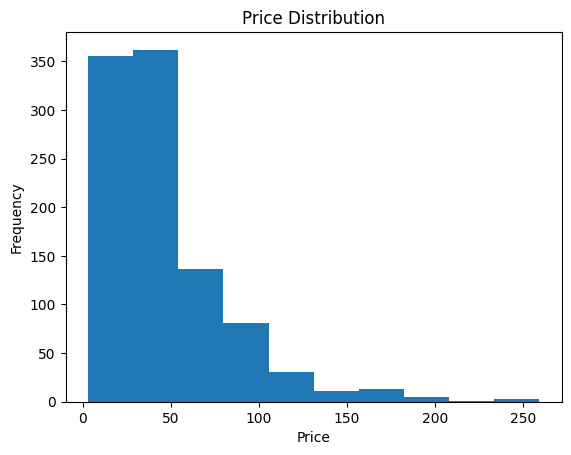

In [ ]:
plt.hist(data["price"])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

Price

Most perfumes are concentrated within specific price ranges.

Some luxury perfumes are priced significantly higher than others.

Text(0, 0.5, 'Frequency')

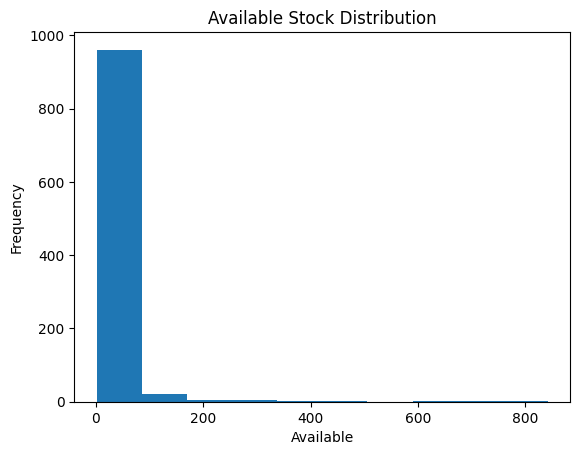

In [ ]:
plt.hist(data["available"])
plt.title("Available Stock Distribution")
plt.xlabel("Available")
plt.ylabel("Frequency")

Available

Stock availability differs across products.

Some perfumes have high inventory, while others have limited stock.

Text(0, 0.5, 'Frequency')

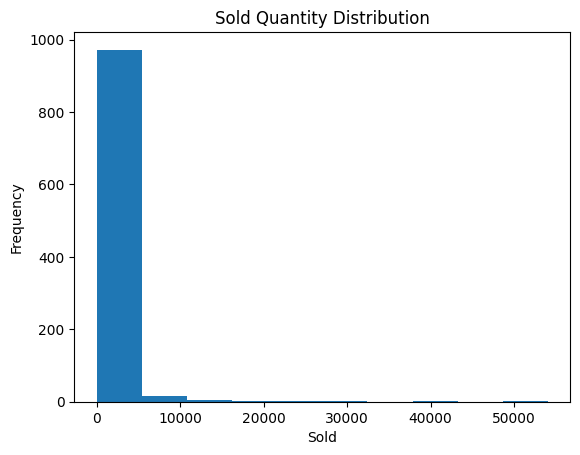

In [ ]:
plt.hist(data["sold"])
plt.title("Sold Quantity Distribution")
plt.xlabel("Sold")
plt.ylabel("Frequency")

Sold

Sold quantities vary among perfumes.

Certain products are more popular and have been sold more frequently.

In [ ]:
data.select_dtypes(include="object").columns

Index(['brand', 'title', 'type', 'priceWithCurrency', 'availableText',
       'lastUpdated', 'itemLocation'],
      dtype='object')

Text(0.5, 1.0, 'Top 10 Brands')

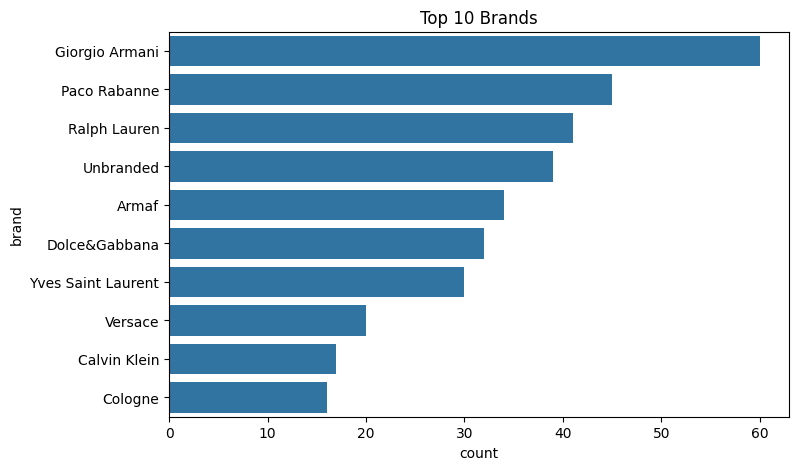

In [ ]:
plt.figure(figsize=(8,5))

top10 = data["brand"].value_counts().index[:10]

sns.countplot(
    data=data,
    y="brand",
    order=top10
)

plt.title("Top 10 Brands")

Text(0.5, 1.0, 'Top 10 Perfume Types')

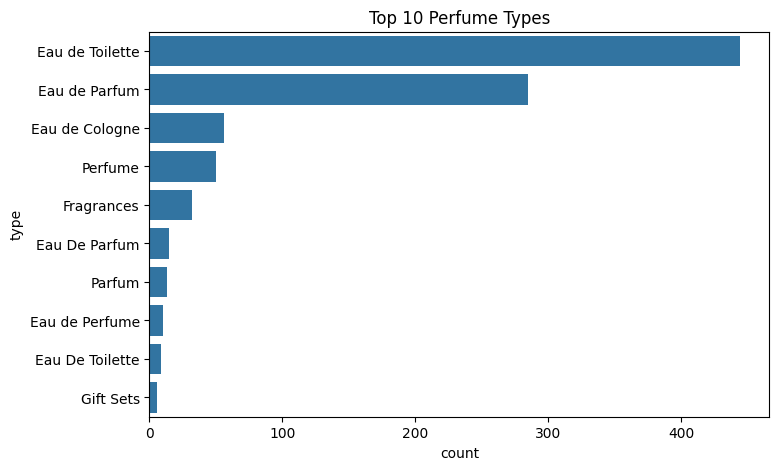

In [ ]:
plt.figure(figsize=(8,5))

top10 = data["type"].value_counts().index[:10]

sns.countplot(
    data=data,
    y="type",
    order=top10
)

plt.title("Top 10 Perfume Types")

Text(0.5, 1.0, 'Top 10 Item Locations')

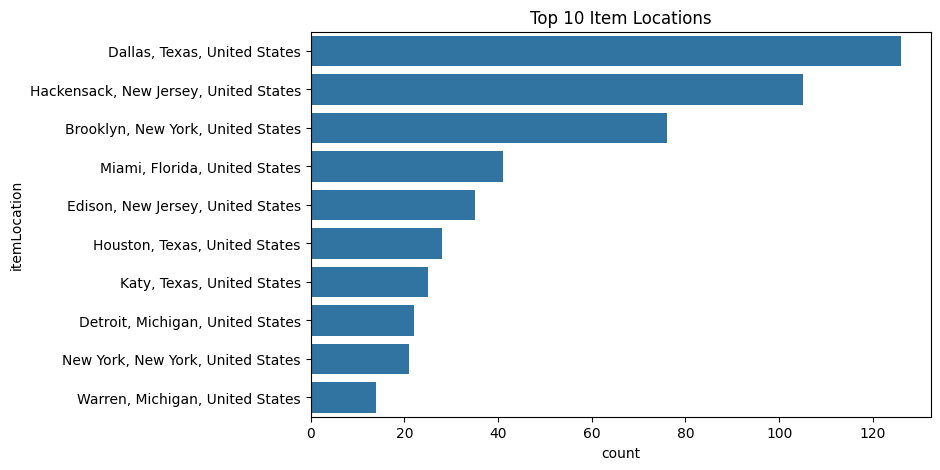

In [ ]:
plt.figure(figsize=(8,5))

top10 = data["itemLocation"].value_counts().index[:10]

sns.countplot(
    data=data,
    y="itemLocation",
    order=top10
)

plt.title("Top 10 Item Locations")

Text(0.5, 1.0, 'Top 10 Availability Status')

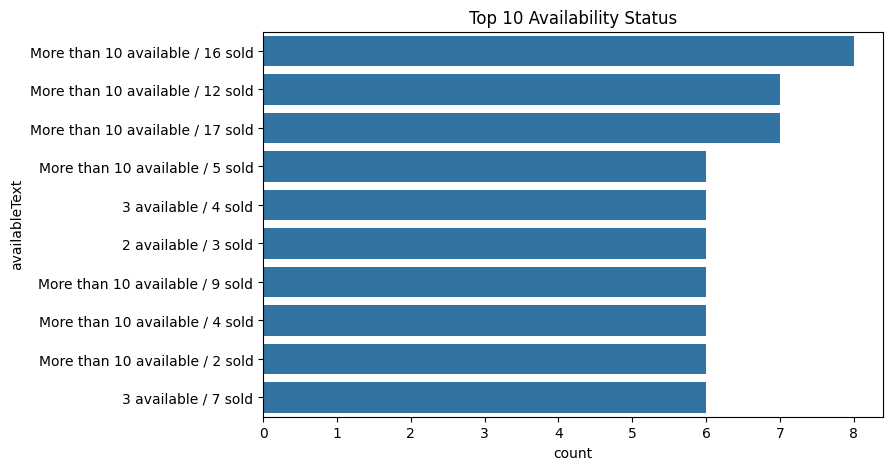

In [ ]:
plt.figure(figsize=(8,5))

top10 = data["availableText"].value_counts().index[:10]

sns.countplot(
    data=data,
    y="availableText",
    order=top10
)

plt.title("Top 10 Availability Status")

Insights

Certain perfume brands are more common in the dataset.

Some fragrance types are more popular than others.

Products are sold from different locations across the marketplace.

Stock availability differs among products.

<Axes: >

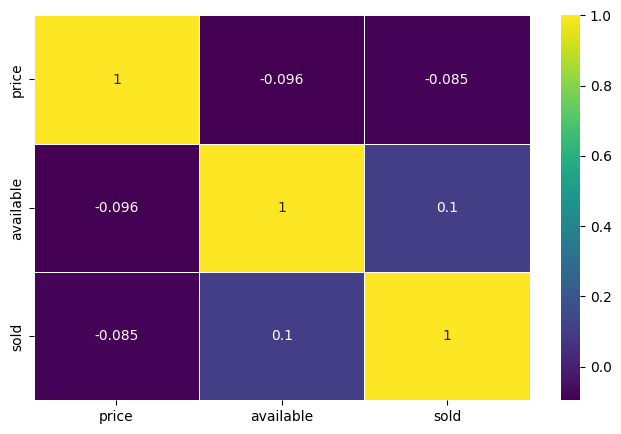

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    data.select_dtypes(include=["float64", "int64"]).corr(),
    annot=True,
    cmap="viridis",
    linewidths=0.5
)

Price is moderately correlated with sold quantity.

Price has a weak relationship with available stock.

Numeric features provide useful information for prediction.

In [ ]:
X = data.drop("price", axis=1)
y = data["price"]

print("Independent Features (X):")
X.columns

Independent Features (X):


Index(['brand', 'title', 'type', 'priceWithCurrency', 'available',
       'availableText', 'sold', 'lastUpdated', 'itemLocation'],
      dtype='object')

In [ ]:
print("\nDependent Feature (y):")
y.name


Dependent Feature (y):


'price'

price is the continuous numerical value that we want to predict, so it is selected as the dependent variable (y).

Features such as brand, type, stock availability, sold quantity, location, and update information may influence the perfume's price.

Therefore, these columns are selected as the independent variables (X).

Since the target variable is continuous, this is a Regression Machine Learning Problem.

In [ ]:
data[["brand", "type"]].head()

,brand,type
0,Dior,Eau de Parfum
1,AS SHOW,Eau de Parfum
2,Unbranded,Eau de Toilette
3,Giorgio Armani,Eau de Toilette
4,Lattafa,Fragrances


In [ ]:
data_encoded = pd.get_dummies(
    data,
    columns=["brand", "type"],
    drop_first=True
)
data_encoded.head()


,title,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,brand_AS PHOTOS,brand_AS PICTURE SHOWN,...,type_Roll On,type_Splash-on,type_Unknown,type_Unscented,type_Various,type_Y,type_cologne,type_edt,type_le parfum,type_~ THE ONE EAU DE PARFUM SPRAY ~
0,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States",False,False,...,False,False,False,False,False,False,False,False,False,False
1,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada",False,False,...,False,False,False,False,False,False,False,False,False,False
2,HOGO BOSS cologne For Men 3.4 oz,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States",False,False,...,False,False,False,False,False,False,False,False,False,False
3,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States",False,False,...,False,False,False,False,False,False,False,False,False,False
4,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,16.91,US $16.91,10.0,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States",False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
data_encoded.columns

Index(['title', 'price', 'priceWithCurrency', 'available', 'availableText',
       'sold', 'lastUpdated', 'itemLocation', 'brand_AS PHOTOS',
       'brand_AS PICTURE SHOWN',
       ...
       'type_Roll On', 'type_Splash-on', 'type_Unknown', 'type_Unscented',
       'type_Various', 'type_Y', 'type_cologne', 'type_edt', 'type_le parfum',
       'type_~ THE ONE EAU DE PARFUM SPRAY ~'],
      dtype='object', length=317)

One-Hot Encoding was used to convert categorical columns into numerical form.

The brand and type columns were encoded because machine learning models cannot directly process text data.

One-Hot Encoding creates separate binary columns for each category without introducing any ranking or order among them.

This makes the data suitable for further preprocessing and model building.

In [ ]:
X = data_encoded.drop("price", axis=1)

In [ ]:
X.dtypes

,0
title,object
priceWithCurrency,object
available,float64
availableText,object
sold,float64
...,...
type_Y,bool
type_cologne,bool
type_edt,bool
type_le parfum,bool


In [ ]:
X = X.select_dtypes(include=["int64", "float64"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
scaled_df.head()

,available,sold
0,-0.153758,-0.202483
1,-0.188190,-0.223798
2,-0.153758,-0.230380
3,-0.291488,-0.189004
4,-0.153758,-0.189944
